# MOBO Workshop Demo

Welcome! This demo shows a complete **Multi-Objective Bayesian Optimization (MOBO)** workflow that only
requires you to provide a single **CSV** with your inputs and objectives, then set a **save path** where
outputs are written.

**You will edit just two things:**
1. `csv_path` → point to your data file
2. `save_path` → directory for results and plots

## Outline
- [0. Setup & Imports](#0-Setup--Imports)
- [1. Load Your Data](#1-Load-Your-Data)  
  - [Existing data present](#Existing-data-present)  
  - [Starting from scratch / LHS](#Starting-from-scratch--LHS)
- [2. Normalize & Convert to Tensors](#Inputs-%E2%86%92-01)
- [3. Fit Gaussian Process (GP) Models](#3-Fit-Gaussian-Process-GP-Models)
- [4. LOOCV Model Selection (optional)](#4-loocv_select_models-optional)
- [5. Posterior Predictions and Diagnostics](#5-Posterior-Predictions-and-Diagnostics)
- [6. Acquisition & Proposing New Batches](#6-Acquisition)
- [7. Candidate Analysis & Visualization](#X_next--Candidate-Analysis)
- [8. Visualize Progress (Hypervolume & Pareto)](#8-Visualize-Progress)
- [9. Save Results](#9-save-outputs)


## 0. Setup & Imports


**Imports** Bring in libraries for data handling, modeling, and plotting.  
If CUDA isn't available, the CPU path still works for a workshop-scale demo.


In [1]:
# --- Imports & setup ---
%load_ext autoreload
%autoreload 2

# Core
import os, sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

parent_dir = os.path.dirname(os.getcwd())
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)

# Torch / BoTorch / GPyTorch
import torch
from mobo_kit.utils import csv_to_config, split_XY, get_objective_names, np_to_torch
from mobo_kit.design import build_design_from_config

from mobo_kit.lhs import lhs_dataframe, lhs_dataframe_optimized
from mobo_kit.constraints import constraints_from_config

from mobo_kit.plotting import plot_distribution, plot_correlation_heatmap, plot_PCA

from mobo_kit.data import x_normalizer_np

from mobo_kit.models import fit_gp_models
from mobo_kit.constraints import check_clausius_clapeyron_np
from mobo_kit.lhs import lhs_dataframe
#from mobo_kit.plotting import plot_pareto, plot_hypervolume_trajectory

# if torch.cuda.is_available():
#     device = torch.device("cuda")
# elif torch.backends.mps.is_available():
#     device = torch.device("mps")
# else:
device = torch.device("cpu")

print(f"Using device: {device}")


Using device: cpu


## Point to CSV and save path

In [2]:
# Path to your CSV (change for your data)
csv_path = "/Users/nickyevans17/MIT Dropbox/Buonassisi-Group/Projects - Active/2025-2027 Toyota/06_DiSCOtoDevice/07_MOBO Code/Data+Results/2604_FA0.9Cs0.1PbI3/Round by round data tracking/Combined rounds/LHS R0_(14 samples + Control)/Round_0_Worklist_wcontrol.csv"
save_path = "/Users/nickyevans17/MIT Dropbox/Buonassisi-Group/Projects - Active/2025-2027 Toyota/06_DiSCOtoDevice/07_MOBO Code/Data+Results/2604_FA0.9Cs0.1PbI3/Round by round data tracking/Combined rounds/R1 + R0"
if not os.path.exists(save_path):
    os.makedirs(save_path, exist_ok=True)
    print(f"Successfully created: {save_path}")

## 1. Load Your Data


## Step 1 — Load CSV → Build Config & Design (two use cases)

This notebook supports **two starting points**:

1) [Existing data present](#Existing-data-present)   
   - CSV has header rows (units/start/stop/step), then data rows.
   - We’ll build a `config`, create a `design`, then split into inputs `X` and objectives `Y`.

2) [Starting from scratch](#starting-from-scratch-no-data-yet)
   - CSV has header rows only (units/start/stop/step), no data rows.
   - We’ll still build `config` and `design`, but skip data split and instead **generate an initial LHS** for you to run in the lab.

> Tip: The expected CSV layout:
> - Row 1: **variable_names**  
> - Row 2: **units**  
> - Row 3: **start** values  
> - Row 4: **stop** values  
> - Row 5: **step** values 
> - Row 6: **empty** 
> - Row 7+: experimental data (if you have any)


<a id="existing-data-present"></a>

### Existing data present

If your CSV already has experimental results (rows 6 and below):

We will:
1. Convert the CSV into a config dictionary.  
2. Build a `Design` object that stores variable ranges and grids.  
3. Split into `X` (inputs) and `Y` (objectives).

In [3]:
# 1. Convert CSV to config dict + YAML
config = csv_to_config(csv_path, output_path=os.path.join("../configs", "FA0.9CS0.1PbI3_260407_Config.yaml"))

# 2. Build design space from config
design = build_design_from_config(config)

# 3. Load CSV fully, then split into X, Y
df = pd.read_csv(csv_path)
X_df, Y_df = split_XY(df, design, config)

print("Design inputs:", design.names)
print("Lower bounds:", design.lowers)
print("Upper bounds:", design.uppers)
print("Steps:", design.steps)
print("Objectives:", config["objectives"]["names"])
print("X shape:", X_df.shape, "Y shape:", Y_df.shape)

display(pd.DataFrame(X_df, columns=design.names).head(20))
obj_names = get_objective_names(config)
display(pd.DataFrame(Y_df, columns=obj_names).head(20))

Design inputs: ['speed_1', 'time_1', 'speed_2', 'time_2', 'precur_conc', 'precur_vol', 'anneal_temp', 'anneal_time', 'anti_vol', 'anti_time']
Lower bounds: [1000.    5.    0.   10.    1.   40.  100.   10.  100.    9.]
Upper bounds: [6.00e+03 5.00e+01 5.00e+03 6.00e+01 2.00e+00 2.00e+02 1.85e+02 6.00e+01
 2.00e+02 2.50e+01]
Steps: [5.e+02 5.e+00 5.e+02 5.e+00 5.e-02 1.e+01 5.e+00 5.e+00 5.e+00 2.e+00]
Objectives: ['Uniformity', 'Thickness', 'Optoelectronic']
X shape: (15, 10) Y shape: (15, 3)


,speed_1,time_1,speed_2,time_2,precur_conc,precur_vol,anneal_temp,anneal_time,anti_vol,anti_time
5,1000.0,10.0,5000.0,40.0,1.40,200.0,100.0,45.0,150.0,12.0
6,5000.0,30.0,0.0,60.0,1.25,160.0,105.0,35.0,145.0,13.0
7,3500.0,35.0,3000.0,35.0,1.90,150.0,110.0,40.0,175.0,25.0
8,2500.0,15.0,1000.0,25.0,1.35,80.0,115.0,30.0,140.0,21.0
9,1500.0,10.0,3500.0,45.0,1.70,100.0,125.0,25.0,200.0,17.0
10,1500.0,45.0,2500.0,50.0,1.95,140.0,125.0,55.0,130.0,11.0
11,4000.0,10.0,5000.0,40.0,1.00,120.0,130.0,50.0,185.0,19.0
12,5000.0,45.0,4000.0,45.0,1.15,60.0,135.0,55.0,130.0,15.0
13,3000.0,40.0,2500.0,10.0,1.55,40.0,145.0,10.0,165.0,11.0
14,5500.0,15.0,3500.0,30.0,1.30,170.0,150.0,20.0,100.0,9.0


,Uniformity,Thickness,Optoelectronic
5,0.66,687.0,3.110000e-08
6,0.59,460.0,1.440000e-08
7,0.56,922.0,2.240000e-08
8,0.01,664.0,2.420000e-08
9,0.42,1024.0,2.710000e-09
10,0.25,1303.0,5.410000e-08
11,0.55,360.0,1.150000e-08
12,0.52,487.0,1.240000e-08
13,0.59,775.0,3.570000e-08
14,0.67,532.0,6.560000e-09


### Starting from scratch / LHS

If your CSV only has the **metadata rows** (variable names, units, start, stop, step) but **no data rows**,  
we generate an **initial batch** of experiments using **Latin Hypercube Sampling (LHS)**.  
This ensures your first experiments cover the parameter space evenly.

We will:
1. Convert the CSV into a config dictionary.  
2. Build a `Design` object that stores variable ranges and grids.  
3. Add constraints (if necessary)
4. Generate an LHS dataframe of a given batch size.

In [ ]:
# 1. Convert CSV to config dict + YAML
yaml_name = "FA0.9CS0.1PbI3_260407_Config.yaml"
config = csv_to_config(csv_path, output_path=os.path.join("../configs", yaml_name))

# 2. Build design space from config
design = build_design_from_config(config)
df = pd.read_csv(csv_path)
obj_names = get_objective_names(config)

#3. Add constraints (if necessary)
row_constraints = [] #aints_from_config(config, design)
max_abs_corr = 0.32

#4. Generate an LHS dataframe of a given batch size.
lhs_batch_size = 14
lhs_df = lhs_dataframe_optimized(design, n=lhs_batch_size, seed=42, row_constraints=row_constraints, max_abs_corr=max_abs_corr, verbose=True)
display(lhs_df)
print(f"Objective names: {obj_names}")


In [ ]:
import numpy as np
import pandas as pd

# 1. Pull the pre-calculated choices from the Design object
# 'var_array' was created by build_design using the 'make_linspace' function
summary_data = []
for i, name in enumerate(design.names):
    # .size gives the number of valid grid points for this parameter
    n_choices = design.var_array[i].size 
    summary_data.append({
        "Parameter": name,
        "Choices": n_choices,
        "Min": design.lowers[i],
        "Max": design.uppers[i],
        "Step": design.steps[i]
    })

# 2. Display the table
space_summary_df = pd.DataFrame(summary_data)
display(space_summary_df)

# 3. Calculate Total Conditions (Product of all choices)
total_conditions = np.prod(space_summary_df["Choices"].values)
print(f"\nTOTAL UNIQUE CONDITIONS IN SEARCH SPACE: {total_conditions:,.0f}")

In [ ]:
import os

# 1. Define filenames
round_num = 0
round_worklist_path = os.path.join(save_path, f"Round_{round_num}_Worklist.csv")

# 2. Create the worklist with empty objective columns
lab_worklist = lhs_df.copy()
for obj in obj_names:
    lab_worklist[obj] = "" 

# 3. Save it
lab_worklist.to_csv(round_worklist_path, index=False)
print(f"DONE: Round {round_num} worklist saved to: {round_worklist_path}")

### Visualize data distribution


#### Standardize inputs to visualize correlation (NE addition 260407)

In [ ]:
from sklearn.preprocessing import StandardScaler

# Standardize the inputs (mean=0, std=1)
scaler = StandardScaler()
lhs_standardized = scaler.fit_transform(lhs_df)

# Convert back to DataFrame
lhs_df_std = pd.DataFrame(lhs_standardized, columns=lhs_df.columns)


In [ ]:
_ = plot_distribution(lhs_df, title="LHS Feature Distributions", save=os.path.join(save_path, "lhs_dist.png"))
_ = plot_correlation_heatmap(lhs_df_std, title="LHS Pearson Correlation", save=os.path.join(save_path, "lhs_corr.png"))
_ = plot_PCA(lhs_df_std, title="LHS PCA (2D)", save=os.path.join(save_path, "lhs_pca.png"))

## 2. Normalize Data and Create Tensors/Arrays


**Inputs.** Scale to [0, 1] per dimension. 

This helps GP hyperparameters learn sensibly. There are utility functions to normalize and standardize the outputs, but this is currently handled internally in `fit_gp_models`.

**Tensors.** Some Botorch functions use tensor objects rather than arrays and vice versa. It's good to have both!


In [4]:
# Inputs → [0,1]
X_np = X_df.to_numpy()  ## Change this line if using different round of data
X_norm = x_normalizer_np(X_np, design)

# Tensors
Y_np = Y_df.to_numpy()
(X_t, Y_t), _ = np_to_torch(X_norm, Y_np, device=device, return_device=True)

print("X_scaled shape:", X_t.shape, "Y_scaled shape:", Y_t.shape)

X_scaled shape: torch.Size([15, 10]) Y_scaled shape: torch.Size([15, 3])


## 3. Fit Gaussian Process (GP) Models


We now fit one **Gaussian Process (GP)** per objective (e.g. PCE, Stability, Repeatability).  
This gives us a flexible, uncertainty-aware model of how the objectives vary with process parameters.

- **Defaults:**  
  - Kernel: `MaternKernel(nu=2.5, ard_num_dims=d)` (smooth, ARD per feature)  
  - Likelihood: `GaussianLikelihood` with an inferred homoskedastic noise level  
    (includes a small positive floor to prevent overfitting)

- **Optional overrides:**  
  - You may pass your own **kernel function(s)** (e.g., RBF, Matern with different ν, etc.)  
  - You may pass **noise priors** (e.g., LogNormal or Gamma) to guide the noise estimate.

This example shows passing custom priors and a kernel to demonstrate how it works, but you can omit them entirely to use the defaults.


In [ ]:
from gpytorch.priors import LogNormalPrior, GammaPrior
from gpytorch.kernels import MaternKernel, RBFKernel, PeriodicKernel, ConstantKernel
from mobo_kit.acquisition import MixedMCMultiOutputObjective
from mobo_kit.models import fit_gp_models_baybe

# Lengthscale prior: GammaPrior(1.2, 2.5) → mode at ~0.08, mean ~0.48 on [0,1]
# This penalizes very large lengthscales, helping to prevent corner-chasing.
#kernel_fn = lambda d: MaternKernel(nu=2.5, ard_num_dims=d, lengthscale_prior=GammaPrior(1.2, 2.5))

# Noise prior: GammaPrior(1.05, 0.1) → tight prior near zero, discourages overfitting noise
#noise_priors = [GammaPrior(1.05, 0.1) for _ in range(3)]

model = fit_gp_models_baybe(X_t, Y_t) #noise_priors=noise_priors, kernel_fn=kernel_fn)


## 4. LOOCV Model Selection (optional)

Instead of hand-choosing kernel functions and noise priors, you can let the repo 
**automatically compare candidates** using **Leave-One-Out Cross-Validation (LOOCV)**.

- The function `loocv_select_models` tries multiple `(kernel × noise)` combinations.
- By default, it uses:
  - **Kernel options:** RBF, Matern(ν=0.5), Matern(ν=1.5), Matern(ν=2.5)  
  - **Noise priors:** `None` (free noise level) and `LogNormal(-4.0, 0.5)`
- For each fold (leave one point out), it re-fits the GP, predicts the held-out point, 
  and records **R²** and **RMSE**.  
- After sweeping all combinations, it selects the best configuration per objective 
  and re-fits on the full dataset.

**Pros:** 
- removes guesswork.
- gives metrics for each option.  

**Cons:** 
- expensive when you have many data points (since it re-fits N×(#kernels×#priors) times).
- poor fits when handling very small and noisy datasets and have convergence errors.

You can skip this step if you are happy with the defaults from Step 3.


In [ ]:
# Optional LOOCV model selection. Disabled by default because it refits many GPs.
run_loocv = False
if run_loocv:
    from mobo_kit.models import loocv_select_models
    model_cv, results_df = loocv_select_models(
        X_t,
        Y_t,
        objective_names=obj_names, # list of objective column names
        device=X_t.device,  # optional; inferred from X_t if omitted
    )
    display(results_df.sort_values(["objective", "rmse"]))
else:
    results_df = pd.DataFrame()
    model_cv = None
    print("Skipping optional LOOCV. Set run_loocv = True to enable it.")

/opt/miniconda3/envs/mobo-fom/lib/python3.10/site-packages/botorch/fit.py:214: OptimizationWarning: `scipy_minimize` terminated with status 3, displaying original message from `scipy.optimize.minimize`: ABNORMAL: 
  result = optimizer(mll, closure=closure, **optimizer_kwargs)
/opt/miniconda3/envs/mobo-fom/lib/python3.10/site-packages/botorch/fit.py:214: OptimizationWarning: `scipy_minimize` terminated with status 3, displaying original message from `scipy.optimize.minimize`: ABNORMAL: 
  result = optimizer(mll, closure=closure, **optimizer_kwargs)
/opt/miniconda3/envs/mobo-fom/lib/python3.10/site-packages/botorch/fit.py:214: OptimizationWarning: `scipy_minimize` terminated with status 3, displaying original message from `scipy.optimize.minimize`: ABNORMAL: 
  result = optimizer(mll, closure=closure, **optimizer_kwargs)
/opt/miniconda3/envs/mobo-fom/lib/python3.10/site-packages/botorch/fit.py:214: OptimizationWarning: `scipy_minimize` terminated with status 3, displaying original messag

[fit_gp_models] obj 2: first fit failed (All attempts to fit the model have failed.); retrying with higher noise floor


/opt/miniconda3/envs/mobo-fom/lib/python3.10/site-packages/botorch/fit.py:214: OptimizationWarning: `scipy_minimize` terminated with status 3, displaying original message from `scipy.optimize.minimize`: ABNORMAL: 
  result = optimizer(mll, closure=closure, **optimizer_kwargs)
/opt/miniconda3/envs/mobo-fom/lib/python3.10/site-packages/botorch/fit.py:214: OptimizationWarning: `scipy_minimize` terminated with status 3, displaying original message from `scipy.optimize.minimize`: ABNORMAL: 
  result = optimizer(mll, closure=closure, **optimizer_kwargs)
/opt/miniconda3/envs/mobo-fom/lib/python3.10/site-packages/botorch/fit.py:214: OptimizationWarning: `scipy_minimize` terminated with status 3, displaying original message from `scipy.optimize.minimize`: ABNORMAL: 
  result = optimizer(mll, closure=closure, **optimizer_kwargs)
/opt/miniconda3/envs/mobo-fom/lib/python3.10/site-packages/botorch/fit.py:214: OptimizationWarning: `scipy_minimize` terminated with status 3, displaying original messag

[fit_gp_models] obj 2: retry failed (All attempts to fit the model have failed.); continuing with initial hyperparameters


/opt/miniconda3/envs/mobo-fom/lib/python3.10/site-packages/botorch/fit.py:214: OptimizationWarning: `scipy_minimize` terminated with status 3, displaying original message from `scipy.optimize.minimize`: ABNORMAL: 
  result = optimizer(mll, closure=closure, **optimizer_kwargs)
/opt/miniconda3/envs/mobo-fom/lib/python3.10/site-packages/botorch/fit.py:214: OptimizationWarning: `scipy_minimize` terminated with status 3, displaying original message from `scipy.optimize.minimize`: ABNORMAL: 
  result = optimizer(mll, closure=closure, **optimizer_kwargs)
/opt/miniconda3/envs/mobo-fom/lib/python3.10/site-packages/botorch/fit.py:214: OptimizationWarning: `scipy_minimize` terminated with status 3, displaying original message from `scipy.optimize.minimize`: ABNORMAL: 
  result = optimizer(mll, closure=closure, **optimizer_kwargs)
/opt/miniconda3/envs/mobo-fom/lib/python3.10/site-packages/botorch/fit.py:214: OptimizationWarning: `scipy_minimize` terminated with status 3, displaying original messag

[fit_gp_models] obj 2: first fit failed (All attempts to fit the model have failed.); retrying with higher noise floor


### Display LOOCV Results

In [ ]:
# Display fitted model details from the default model (in source code).
for i, gp in enumerate(model.models):
    print(f"--- Model {i+1} ({obj_names[i]}) ---")
    kernel = gp.covar_module.base_kernel
    print("Kernel:", type(kernel).__name__)
    if hasattr(kernel, "nu"):
        print("Matern nu:", kernel.nu)
    prior_type = type(getattr(gp.likelihood.noise_covar, "noise_prior", None)).__name__
    print("Noise prior:", prior_type)
    print("Lengthscales:", gp.covar_module.base_kernel.lengthscale.detach().cpu().numpy().flatten())
    print("Outputscale:", gp.covar_module.outputscale.item())
    print("Noise:", gp.likelihood.noise.item())
    print()

,kernel,noise_prior,objective,r2,rmse
0,kernel_0,noise_0,Uniformity,-0.606,0.227
1,kernel_0,noise_0,Thickness,0.321,195.274
2,kernel_0,noise_0,Optoelectronic,-1.969,0.000
3,kernel_0,noise_1,Uniformity,-0.590,0.226
4,kernel_0,noise_1,Thickness,0.328,194.291
5,kernel_0,noise_1,Optoelectronic,-1.255,0.000
6,kernel_1,noise_0,Uniformity,-0.396,0.211
7,kernel_1,noise_0,Thickness,0.660,138.197
8,kernel_1,noise_0,Optoelectronic,-0.918,0.000
9,kernel_1,noise_1,Uniformity,-0.530,0.221


--- Model 1 (Uniformity) ---
Kernel: MaternKernel
Matern ν: 0.5
Noise prior: None
Lengthscales: [2.80123775e+03 1.54283153e-01 1.33757789e+03 2.51551446e+03
 2.36919343e+03 2.64407911e-01 2.37986432e+03 1.87895842e+03
 1.18618655e+03 1.25877607e+03]
Outputscale: 0.9275717559361558
Noise: 0.0010000000474974513

--- Model 2 (Thickness) ---
Kernel: MaternKernel
Matern ν: 0.5
Noise prior: GammaPrior
Lengthscales: [2.10312417e+00 1.03799435e+04 1.01955916e+04 9.51612740e+03
 1.73839686e+00 9.66769527e+03 8.15802285e+03 9.19877145e+03
 9.88382416e+03 8.90494896e+03]
Outputscale: 1.7906711489244482
Noise: 0.0010000000474974513

--- Model 3 (Optoelectronic) ---
Kernel: MaternKernel
Matern ν: 0.5
Noise prior: GammaPrior
Lengthscales: [1.54511021e+04 2.17043522e+04 2.98863563e+00 2.18973897e+03
 5.13606068e+03 4.20996064e+03 1.19424291e+04 2.66684643e+00
 6.19550078e+03 5.44884319e-02]
Outputscale: 0.7892035746852851
Noise: 0.01899260768339013



## 5. Posterior Predictions & Diagnostics


With a fitted GP model (`model` from Step 3 or 4), we can now evaluate how well it explains the data.  
This step does two things:

1. **Posterior predictions:**  
   - Use `posterior_report(model, X_t)` to get the **predicted mean** and **uncertainty (std)** for each objective at the training points.  
   - These predictions are automatically converted back into the original units (because the model internally standardizes outputs).

2. **Diagnostics:**  
   - `plot_parity_np` shows **predicted vs. true values** for each objective, with optional error bars from the GP’s predictive uncertainty.  
   - `plot_shap` estimates **feature importance** (mean absolute SHAP values per input dimension), so you can see which process parameters most influence each objective.  
   - `compute_metrics` calculates **R²** and **RMSE**, and can also return per-point residuals and z-scores to help check model fit quality.

/opt/miniconda3/envs/mobo-fom/lib/python3.10/site-packages/gpytorch/distributions/multivariate_normal.py:375: NumericalWarning: Negative variance values detected. This is likely due to numerical instabilities. Rounding negative variances up to 1e-10.
  warnings.warn(


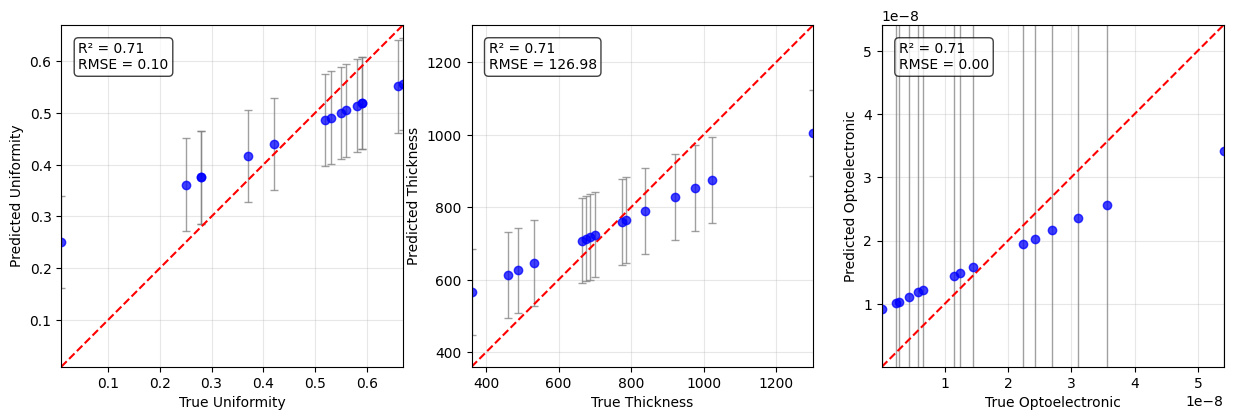

Generating SHAP bar plot for Uniformity...


  0%|          | 0/15 [00:00<?, ?it/s]

⚠️  SHAP values are ~0 for Uniformity. The GP may be nearly flat or the background is too large/similar.
Generating SHAP bar plot for Thickness...


  0%|          | 0/15 [00:00<?, ?it/s]

⚠️  SHAP values are ~0 for Thickness. The GP may be nearly flat or the background is too large/similar.
Generating SHAP bar plot for Optoelectronic...


  0%|          | 0/15 [00:00<?, ?it/s]

⚠️  SHAP values are ~0 for Optoelectronic. The GP may be nearly flat or the background is too large/similar.
pred mean range Optoelectronic: 0.45733287460433536 0.45733287460433536


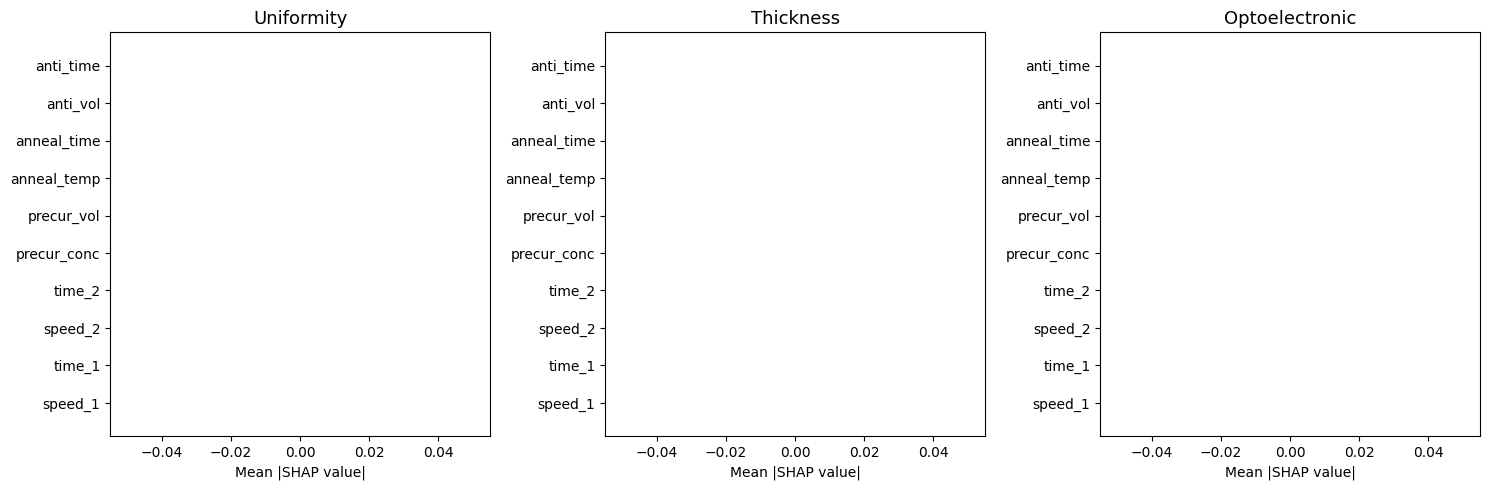

,Objective,R2,RMSE,Residual,Z-score
0,Uniformity,0.710,0.096,"[-0.10907553804402803, -0.07140150655945676, -...","[-1.2232376858817133, -0.8007387835850318, -0...."
1,Thickness,0.713,126.982,"[31.567650145526045, 153.1693255779619, -94.31...","[0.2670221438103145, 1.2956175544667192, -0.79..."
2,Optoelectronic,0.712,0.000,"[-7.574762201341161e-09, 1.3800125569060942e-0...","[-0.0007574762201341161, 0.0001380012556906094..."


In [ ]:
from mobo_kit.models import posterior_report
from mobo_kit.plotting import plot_parity_np, plot_shap
from mobo_kit.metrics import compute_metrics
pred_mean, pred_std = posterior_report(model, X_t)
fig_train, metrics_train = plot_parity_np(
    Y_np,
    pred_mean,
    pred_std,
    objective_names=obj_names,
    save=str(save_path / "parity_train.png"),
)
run_shap = False
if run_shap:
    # plot_shap calls the fitted GP posterior directly, so explain the same
    # normalized input space used to train the model.
    fig_shap = plot_shap(
        design,
        X_norm,
        model,
        objective_names=obj_names,
        save=str(save_path / "shap.png"),
    )
else:
    fig_shap = None
    print("Skipping SHAP by default to keep memory usage low. Set run_shap = True to enable it.")
metrics_df = compute_metrics(
    true_Y=Y_np,
    pred_mean=pred_mean,
    pred_std=pred_std,
    objective_names=obj_names,
    add_residuals=True,
    add_zscores=True,
)
display(metrics_df)

## 6. Acquisition: Pareto Front & Proposing New Experiments

With our GP model trained, we now use an **acquisition function** to decide *where to sample next*.  
In multi-objective BO, we look for candidates that **expand the Pareto front** and improve **hypervolume**.

### Pareto Front & Hypervolume
- The **Pareto front** consists of non-dominated points: no other point is strictly better across *all* objectives.  
- The **hypervolume** measures the space dominated by the Pareto front relative to a chosen **reference point**.  
- As we add better candidates, the hypervolume increases.

In [10]:
from mobo_kit.metrics import compute_ref_pareto_hv
from mobo_kit.acquisition import MixedMCMultiOutputObjective
from botorch.utils.multi_objective.pareto import is_non_dominated

# 1. Define your optimization directions for each objective.
# Make sure the order matches your CSV columns!
# Options: 'max', 'min', ('match', target_value)
directions = ['max', ('match', 650.0), 'max'] #[uniformity, thickness, optoelectronic score]

# Initialize our custom objective
custom_objective = MixedMCMultiOutputObjective(directions)

Y_t_transformed = custom_objective(Y_t)

# 2. Define the Reference Point in ORIGINAL UNITS (before any transformations) real world values for the worst acceptable outcomes for each objective
#original_ref_point = torch.tensor(
   # [1.01, 1000.01, -0.01], # Assuming 700 is worst acceptable for the 650 match goal (250 units away)
   # dtype=X_t.dtype, 
   # device=X_t.device
#)

# 3. Define the Reference Point (Worst Acceptable Values)
# Since our custom objective tricks BoTorch into maximizing everything, 
# you MUST manually apply the same transformation to your reference point.
#
# Transformation Rules:
# - If 'max': Keep the worst acceptable value exactly as it is.
#             (e.g., you want PCE > 10.0 -> use 10.0)
# - If 'min': Multiply your worst acceptable value by -1.
#             (e.g., you want Error < 0.5 -> use -0.5)
# - If 'match': Calculate the negative absolute distance from your target.
#               Formula: -abs(worst_acceptable_value - target)
#               (e.g., Target is 50, worst acceptable is 70 -> use -20.0)

#transformed_ref_point_t = torch.tensor(
   # [-1.01, -300.01, -0.01], # <--- UPDATE THESE BASED ON YOUR DIRECTIONS
   # dtype=X_t.dtype, 
   # device=X_t.device
#)

transformed_ref_point_t, pareto_Y_t_transformed, hv_val = compute_ref_pareto_hv(Y_t_transformed)
print("Hypervolume:", hv_val)
print("Transformed ref point:", transformed_ref_point_t.cpu().numpy())
pareto_mask = is_non_dominated(Y_t_transformed)
pareto_Y_t_real_world = Y_t[pareto_mask]

print("Pareto count:", pareto_Y_t_real_world.shape[0])
print(pareto_Y_t_real_world)

Hypervolume: 1.8018558273282017e-05
Transformed ref point: [ 9.99999e-03 -6.53000e+02 -9.93940e-09]
Pareto count: 6
tensor([[6.6000e-01, 6.8700e+02, 3.1100e-08],
        [1.0000e-02, 6.6400e+02, 2.4200e-08],
        [2.5000e-01, 1.3030e+03, 5.4100e-08],
        [5.9000e-01, 7.7500e+02, 3.5700e-08],
        [6.7000e-01, 5.3200e+02, 6.5600e-09],
        [5.8000e-01, 6.7600e+02, 4.3200e-09]], dtype=torch.float64)


### Proposing New Candidates

We then call `propose_batch`, which:
1. Builds a **qLogNoisyExpectedHypervolumeImprovement** acquisition function (default).
2. Optimizes it over the normalized design space.
3. Converts back to **physical units**, snapping to valid grids.
4. Enforces row constraints (e.g. Clausius–Clapeyron).
5. Returns a batch of promising candidates.

You can also add **outcome constraints** (e.g. enforce PCE ≥ 15%).

### Balancing Exploration vs. Exploitation

The following parameters influence the tradeoff:
- num_restarts and raw_samples: higher values → more global search (exploration).
- sample_shape (MC samples): larger → more accurate acquisition evaluation, but slower.
- sequential:
    - True → proposes candidates one-by-one, each conditioned on the last (more exploitative).
    - False → proposes all in parallel (more exploratory, but less coordinated).
- Outcome constraints can bias selection toward “safe” regions, shifting away from exploration.

In practice:
- For early rounds, set larger raw_samples (e.g. 1024) and keep sequential=False to encourage exploration.
- For later rounds, reduce these and turn sequential=True to refine promising regions (exploitation).

In [62]:
from mobo_kit.acquisition import propose_batch, outcome_ge, outcome_le

row_constraints = [] #constraints_from_config(config, design)
# Optional: Add outcome constraints here if needed (e.g., minimum acceptable values)
# Note: If you add outcome constraints, make sure the thresholds are in the 
# ORIGINAL real-world units, as they are applied *after* the GP predicts.
#
#upper_thickness= 1000  
#lower_thickness = 300  
# outcome_constraints = [outcome_ge(obj_idx=0, thresh=pce_threshold)]
#outcome_constraints = [
#        outcome_ge(obj_idx=1, thresh=upper_thickness),  # Thickness <= 1000 nm
#        outcome_le(obj_idx=1, thresh=lower_thickness),  # Thickness >= 300 nm
#    ]

out = propose_batch(
    design=design, 
    model=model, 
    train_X=X_t, 
    ref_point_t=transformed_ref_point_t,
    batch_size=5, 
    row_constraints=row_constraints, 
    objective=custom_objective,
    num_restarts=10,       # was 5 → more restarts = better local optima
    raw_samples=4096,       # was 64 → broader initial search
    use_lognehvi=True,
    verbose=True,
    sequential=True,       # keep True: each candidate builds on the last (exploitation)
    sample_shape=256,      # ↑ 128→512: more accurate MC acquisition estimates
)


/opt/miniconda3/envs/mobo-fom/lib/python3.10/site-packages/linear_operator/utils/cholesky.py:41: NumericalWarning: A not p.d., added jitter of 1.0e-08 to the diagonal
  warnings.warn(
/opt/miniconda3/envs/mobo-fom/lib/python3.10/site-packages/linear_operator/utils/cholesky.py:41: NumericalWarning: A not p.d., added jitter of 1.0e-08 to the diagonal
  warnings.warn(
/opt/miniconda3/envs/mobo-fom/lib/python3.10/site-packages/linear_operator/utils/cholesky.py:41: NumericalWarning: A not p.d., added jitter of 1.0e-08 to the diagonal
  warnings.warn(
/opt/miniconda3/envs/mobo-fom/lib/python3.10/site-packages/linear_operator/utils/cholesky.py:41: NumericalWarning: A not p.d., added jitter of 1.0e-08 to the diagonal
  warnings.warn(


In [63]:
# --- BLOCK 2: NEXT ROUND SUGGESTIONS ---
# Convert the AI's suggested physical points into a DataFrame
X_next_df = pd.DataFrame(out["X_phys"], columns=design.names)

# Add empty columns for your results
for obj in obj_names:
    X_next_df[obj] = ""

# Save as the "Next Round" file
next_round_path = os.path.join(save_path, "Next_Round_Worklist-test.csv")
X_next_df.to_csv(next_round_path, index=False)

print(f"Next lab batch saved to: {next_round_path}")
display(X_next_df)

Next lab batch saved to: /Users/nickyevans17/MIT Dropbox/Buonassisi-Group/Projects - Active/2025-2027 Toyota/06_DiSCOtoDevice/07_MOBO Code/Data+Results/2604_FA0.9Cs0.1PbI3/Round by round data tracking/Combined rounds/R1 + R0/Next_Round_Worklist-test.csv


,speed_1,time_1,speed_2,time_2,precur_conc,precur_vol,anneal_temp,anneal_time,anti_vol,anti_time,Uniformity,Thickness,Optoelectronic
0,5000.0,45.0,4000.0,45.0,1.15,60.0,135.0,55.0,130.0,15.0,,,
1,4500.0,35.0,1500.0,35.0,1.50,120.0,175.0,15.0,120.0,23.0,,,
2,1000.0,10.0,5000.0,40.0,1.40,200.0,100.0,45.0,150.0,13.0,,,
3,5000.0,45.0,4000.0,45.0,1.15,60.0,135.0,55.0,130.0,15.0,,,
4,4500.0,35.0,1500.0,35.0,1.50,110.0,180.0,15.0,120.0,23.0,,,


In [64]:
print(out.keys())

dict_keys(['X_phys', 'X_norm', 'acq_val', 'attempts'])


## 7. Review Proposed Batch & Predicted Outcomes

Now that we’ve generated candidates, let’s:
1) **Inspect the proposed settings** in original (physical) units.  
2) **Interpret acquisition values** (log nEHVI → EHVI).  
3) **Preview model predictions** (mean ± uncertainty) for each objective at the proposed points.

### 1) Inspect the proposed candidates
- `out["X_phys"]` is already **de-normalized and snapped** to any discrete grids defined in the `Design`.
- We display it as a tidy dataframe with the original column names.

### 2) Acquisition values (how “good” each candidate is)
- With `use_lognehvi=True` (default), `out["acq_val"]` contains **log(EHVI)** for numerical stability.  
- Exponentiate to get **EHVI** (expected hypervolume improvement).  
- Larger EHVI ⇒ greater expected contribution to the Pareto front.

### 3) Predicted outcomes for the proposed batch
- We pass the **normalized** candidates (`out["X_norm"]`) through the fitted model.  
- The bar plot shows **mean** predictions with **uncertainty bars** (predictive std) for each objective.

> Notes
> - Objectives are assumed to be **maximized** here. If you minimize any objective, flip the sign upstream for consistency.
> - Before running the batch in the lab, you can optionally **save** the table to CSV (e.g., `X_next.to_csv(...)`) to hand off to execution.



array([[5.00e+03, 4.50e+01, 4.00e+03, 4.50e+01, 1.15e+00, 6.00e+01,
        1.35e+02, 5.50e+01, 1.30e+02, 1.50e+01],
       [4.50e+03, 3.50e+01, 1.50e+03, 3.50e+01, 1.50e+00, 1.20e+02,
        1.75e+02, 1.50e+01, 1.20e+02, 2.30e+01],
       [1.00e+03, 1.00e+01, 5.00e+03, 4.00e+01, 1.40e+00, 2.00e+02,
        1.00e+02, 4.50e+01, 1.50e+02, 1.30e+01],
       [5.00e+03, 4.50e+01, 4.00e+03, 4.50e+01, 1.15e+00, 6.00e+01,
        1.35e+02, 5.50e+01, 1.30e+02, 1.50e+01],
       [4.50e+03, 3.50e+01, 1.50e+03, 3.50e+01, 1.50e+00, 1.10e+02,
        1.80e+02, 1.50e+01, 1.20e+02, 2.30e+01]])

Acquisition Value Analysis:
   Raw acquisition values (log(nEHVI)): ['-4.554884', '-11.828097', '-11.774440', '-8.475744', '-4.506176']
   Actual EHVI values: ['0.010516', '0.000007', '0.000008', '0.000208', '0.011041']


/opt/miniconda3/envs/mobo-fom/lib/python3.10/site-packages/gpytorch/distributions/multivariate_normal.py:375: NumericalWarning: Negative variance values detected. This is likely due to numerical instabilities. Rounding negative variances up to 1e-10.
  warnings.warn(


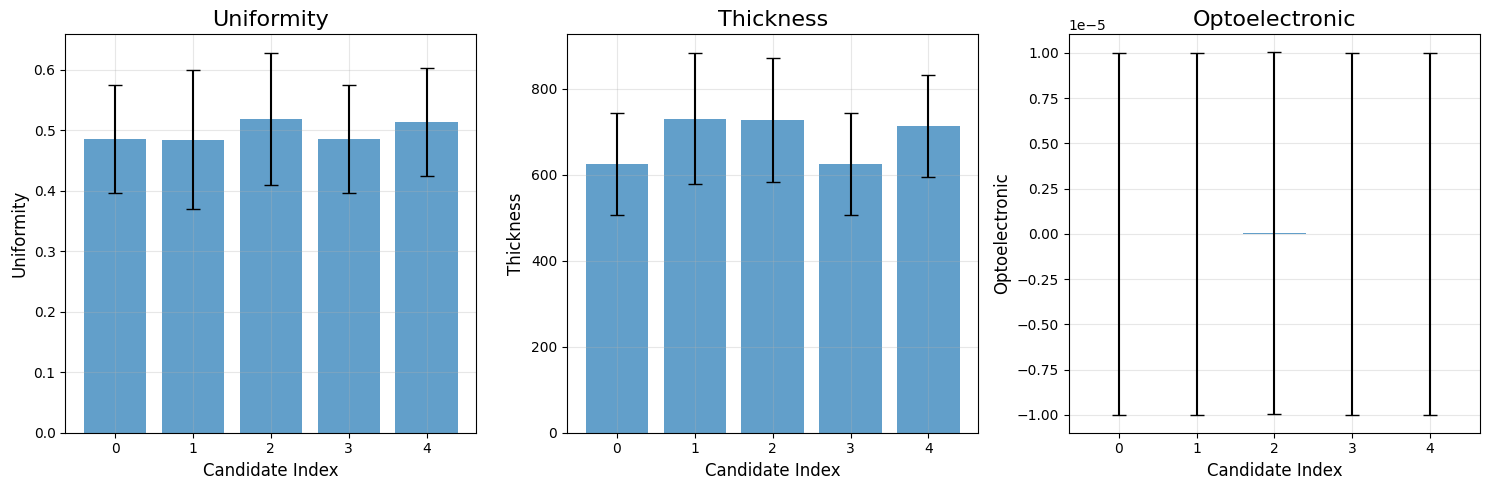

In [65]:
from mobo_kit.plotting import plot_bar

# 1. Display proposed candidates
X_next = out["X_phys"]
X_next_df = pd.DataFrame(out["X_phys"], columns=design.names)
display(X_next)

# 2. Acquisition value analysis
print(f"Acquisition Value Analysis:")
print(f"   Raw acquisition values (log(nEHVI)): {[f'{v:.6f}' for v in out['acq_val']]}")
# Convert from log(EHVI) to EHVI since use_lognehvi=True (default)
ehvi_values = [np.exp(v) for v in out['acq_val']]
print(f"   Actual EHVI values: {[f'{v:.6f}' for v in ehvi_values]}")

# 3. Predicted outcomes for the proposed batch
X_norm = out["X_norm"]
X_norm_t = np_to_torch(X_norm, device=X_t.device)
pred_mean_new, pred_std_new = posterior_report(model, X_norm_t)

fig_bar = plot_bar(pred_mean_new, pred_std_new, labels=obj_names, save=os.path.join(save_path, "proposed_bar-test.png"))

## 8. Visualize Your Progress (Work in Progress...)

We track learning progress by plotting the **hypervolume (HV)** after each batch of **observed** results.  
As you collect new data and the Pareto front improves, HV should **monotonically increase** (or stay flat).

**Key points**
- Use **observed outcomes** (not predictions).  
- Keep a **fixed reference point** `ref_point_t` across all batches (choose it once at the start, slightly worse than the worst feasible values for each objective, in original units).  
- Compute HV on the **cumulative dataset** up through each batch.

Current HV (observed data): 0.000018 | Pareto count: 6
Demo HV with predictions: 0.000018 | Pareto count: 7


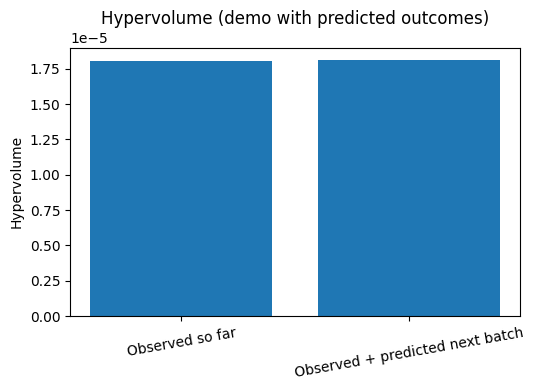

In [66]:
# -------------------------------------------------------------------
# 1) Re-use the HV calculated in Section 6 for our observed data
# -------------------------------------------------------------------
print(f"Current HV (observed data): {hv_val:.6f} | Pareto count: {pareto_Y_t_real_world.shape[0]}")

# 3) Append predicted means for proposed batch
Y_next_t = torch.tensor(pred_mean_new, dtype=Y_t.dtype, device=Y_t.device)

# CRITICAL: We must transform the newly predicted points using our custom 
# objective before we can calculate the combined hypervolume!
Y_next_t_transformed = custom_objective(Y_next_t)
combined_Y_transformed = torch.cat([Y_t_transformed, Y_next_t_transformed], dim=0)

# -------------------------------------------------------------------
# 3) Calculate new HV on the combined transformed data
# -------------------------------------------------------------------
_, pareto_Y_combined_transformed, hv_val_combined = compute_ref_pareto_hv(
    combined_Y_transformed, 
    transformed_ref_point_t.cpu().numpy()
)
print(f"Demo HV with predictions: {hv_val_combined:.6f} | Pareto count: {pareto_Y_combined_transformed.shape[0]}")

# 4) Simple before/after plot
hv_vals = [hv_val, hv_val_combined]
labels = ["Observed so far", "Observed + predicted next batch"]

plt.figure(figsize=(5.5, 4))
plt.bar(range(len(hv_vals)), hv_vals)
plt.xticks(range(len(hv_vals)), labels, rotation=10)
plt.ylabel("Hypervolume") #transformed units
plt.title("Hypervolume (demo with predicted outcomes)")
plt.tight_layout()
plt.savefig(os.path.join(save_path, "hv_demo_with_predictions-test.png"), dpi=200)
plt.show()

This plot shows the **current Pareto front** (green) in 3D objective space and an optional **predicted next batch**.  

The **reference point** is drawn as a red star.

In [38]:
# --- Settings: mark which objectives are maximized ---
# We want to plot the real-world values, but for visual clarity, we flip 
# minimized or matched objectives so that "up/right" always means "better".

def prepare_plot_data(Y_tensor_real, directions):
    """Flips real-world data for plotting so Higher = Better for all axes."""
    Y_np = Y_tensor_real.detach().cpu().numpy().copy() if torch.is_tensor(Y_tensor_real) else np.copy(Y_tensor_real)
    for j, direction in enumerate(directions):
        if direction == 'min':
            Y_np[:, j] = -Y_np[:, j]  # Flip min so higher on graph = better
        elif isinstance(direction, tuple) and direction[0] == 'match':
            target = direction[1]
            Y_np[:, j] = -np.abs(Y_np[:, j] - target) # Flip to negative distance
    return Y_np

# Prepare arrays (Pareto + reference point, both already in ORIGINAL units)
pareto_Y_np_plot = prepare_plot_data(pareto_Y_t_real_world, directions)
ref_point_np_plot = prepare_plot_data(original_ref_point.view(1, -1), directions)

has_next = 'Y_next_t' in globals()
if has_next and Y_next_t is not None:
    next_Y_np_plot = prepare_plot_data(Y_next_t, directions)

# --- 3D scatter ---
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

# Pareto points (observed)
ax.scatter(
    pareto_Y_np_plot[:, 0], pareto_Y_np_plot[:, 1], pareto_Y_np_plot[:, 2],
    c='green', s=50, label='Pareto (observed)', depthshade=True
)

# Proposed predicted next batch
if has_next and Y_next_t is not None:
    ax.scatter(
        next_Y_np_plot[:, 0], next_Y_np_plot[:, 1], next_Y_np_plot[:, 2],
        c='orange', s=60, marker='^', label='Proposed (predicted)', depthshade=True
    )

# Reference point
ax.scatter(
    ref_point_np_plot[0, 0], ref_point_np_plot[0, 1], ref_point_np_plot[0, 2],
    c='red', s=80, marker='*', label='Reference point'
)

# Axis labels (update names to your objectives if needed)
axis_labels = []
for i, d in enumerate(directions):
    name = obj_names[i]
    if d == 'max': lbl = f"{name} (max)"
    elif d == 'min': lbl = f"-{name} (flipped min)"
    elif isinstance(d, tuple) and d[0] == 'match': lbl = f"-|{name} - {d[1]}| (match)"
    else: lbl = name
    axis_labels.append(lbl)

ax.set_xlabel(axis_labels[0], fontsize=11)
ax.set_ylabel(axis_labels[1], fontsize=11)
ax.set_zlabel(axis_labels[2], fontsize=11)

ax.set_title('Pareto Front (3D)', fontsize=13)
ax.legend(loc='best')
ax.view_init(elev=25, azim=-45)
plt.tight_layout()
# Optionally save:
# plt.savefig(os.path.join(save_path, "pareto_3d.png"), dpi=200)
plt.show()


NameError: name 'original_ref_point' is not defined

## 9. Save Outputs


Get it right back into that same file format you so tirelessly created!


In [68]:
Y_next_df = pd.DataFrame(pred_mean_new, columns=obj_names)
df_new = pd.concat([X_next_df, Y_next_df], axis=1)

df_batch_1 = pd.concat([df, df_new], axis=0)
df_batch_1.to_csv(os.path.join(save_path, "batch_1-1-test.csv"), index=False)

In [69]:
# 1. Prepare the predicted outcomes (already in real physical units)
Y_pred_df = pd.DataFrame(pred_mean_new, columns=obj_names)

# 2. Prepare the input features 
# We use errors='ignore' so that if the objective columns were already 
# stripped away, the code won't crash.
X_features_only = X_next_df.drop(columns=obj_names, errors='ignore')

# 3. Combine them side-by-side
predictions_record = pd.concat([X_features_only, Y_pred_df], axis=1)

# 4. Save to CSV
output_file = os.path.join(save_path, "Next_Round_Predictions_test.csv")
predictions_record.to_csv(output_file, index=False)

print(f"SUCCESS: Next round predictions saved to: {output_file}")
display(predictions_record)

SUCCESS: Next round predictions saved to: /Users/nickyevans17/MIT Dropbox/Buonassisi-Group/Projects - Active/2025-2027 Toyota/06_DiSCOtoDevice/07_MOBO Code/Data+Results/2604_FA0.9Cs0.1PbI3/Round by round data tracking/Combined rounds/R1 + R0/Next_Round_Predictions_test.csv


,speed_1,time_1,speed_2,time_2,precur_conc,precur_vol,anneal_temp,anneal_time,anti_vol,anti_time,Uniformity,Thickness,Optoelectronic
0,5000.0,45.0,4000.0,45.0,1.15,60.0,135.0,55.0,130.0,15.0,0.486273,625.705690,1.485244e-08
1,4500.0,35.0,1500.0,35.0,1.50,120.0,175.0,15.0,120.0,23.0,0.484687,730.252650,1.413983e-08
2,1000.0,10.0,5000.0,40.0,1.40,200.0,100.0,45.0,150.0,13.0,0.518738,727.977187,2.127234e-08
3,5000.0,45.0,4000.0,45.0,1.15,60.0,135.0,55.0,130.0,15.0,0.486273,625.705690,1.485244e-08
4,4500.0,35.0,1500.0,35.0,1.50,110.0,180.0,15.0,120.0,23.0,0.513980,713.460243,1.110505e-08
